# 🧠 EXTRA WORK: LSTM & Time Series Analysis

---

**Project:** Accuracy Improvement Challenge  
**Notebook:** 06 - LSTM Deep Learning (Bonus Extra Work)  
**Author:** Manish Kumar  
**Date:** 2025  

---

## 🎯 Objective

**Extra Bonus Work:**

1. 📚 Learn about **Time Series Analysis**
2. 🧠 Understand **LSTM (Long Short-Term Memory)** networks
3. 🔬 Apply LSTM to admission prediction problem
4. 📊 Compare LSTM with traditional ML models
5. 📝 Prepare summary insights

---

## 📚 What is Time Series Analysis?

**Time Series** = Data collected over time at regular intervals

**Examples:**
- Stock prices (daily)
- Weather data (hourly)
- Sales figures (monthly)
- Admission trends (yearly)

**Key Concepts:**
- **Trend** - Long-term direction
- **Seasonality** - Repeating patterns
- **Cycles** - Non-fixed patterns
- **Noise** - Random variation

---

## 🧠 What is LSTM?

**LSTM = Long Short-Term Memory**

A special type of **Recurrent Neural Network (RNN)** designed to:
- ✅ Remember information for long periods
- ✅ Handle sequential data
- ✅ Overcome vanishing gradient problem
- ✅ Capture temporal dependencies

### 🔧 LSTM Architecture:

In [1]:
# ============================================================
#  LIBRARY IMPORTS - DEEP LEARNING
# ============================================================

import os
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# TensorFlow / Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 65)
print("  ✅ ALL LIBRARIES LOADED SUCCESSFULLY")
print("=" * 65)
print(f"  📅 Started at        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  🐍 TensorFlow Version: {tf.__version__}")
print(f"  🧠 Keras Available   : ✅")
print(f"  🎲 Random Seed       : 42")
print("=" * 65)

  ✅ ALL LIBRARIES LOADED SUCCESSFULLY
  📅 Started at        : 2026-07-19 23:46:33
  🐍 TensorFlow Version: 2.21.0
  🧠 Keras Available   : ✅
  🎲 Random Seed       : 42


In [2]:
# ============================================================
#  LOAD ENGINEERED DATASET
# ============================================================

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

# Load engineered dataset
df = pd.read_csv(DATA_PROCESSED / "admission_engineered.csv")
df.columns = df.columns.str.strip()

target_col = [col for col in df.columns if 'Admit' in col][0]

print("=" * 65)
print("  📂 DATASET LOADED FOR LSTM EXPERIMENT")
print("=" * 65)
print(f"  📊 Shape         : {df.shape}")
print(f"  🎯 Target        : '{target_col}'")
print(f"  📋 Features      : {df.shape[1] - 1}")
print("=" * 65)

display(df.head())

  📂 DATASET LOADED FOR LSTM EXPERIMENT
  📊 Shape         : (500, 34)
  🎯 Target        : 'Chance of Admit'
  📋 Features      : 33


,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,GRE_x_CGPA,TOEFL_x_CGPA,...,GRE_to_TOEFL_ratio,CGPA_Achievement,Test_Performance,CGPA_Category,GRE_Category,TOEFL_Category,High_Achiever,Mean_All_Scores,Score_Consistency,Total_Weighted_Score
0,328,119,5,5.0,5.0,9.63,0,0.84,3158.64,1145.97,...,2.756303,0.963,0.91250,3,3,3,1,0.986562,0.016637,123.405
1,318,96,3,1.0,1.0,7.23,0,0.34,2299.14,694.08,...,3.312500,0.723,0.56250,1,2,0,0,0.576382,0.310978,105.055
2,304,106,1,4.0,2.0,8.46,0,0.34,2571.84,896.76,...,2.867925,0.846,0.60000,2,0,2,0,0.670575,0.185302,109.560
3,332,108,2,4.5,1.0,8.08,0,0.52,2682.56,872.64,...,3.074074,0.808,0.80000,2,3,2,0,0.697412,0.283519,114.130
4,297,105,1,1.5,3.5,7.88,1,0.38,2340.36,827.40,...,2.828571,0.788,0.54375,1,0,2,0,0.622755,0.213642,106.480


In [3]:
# ============================================================
#  DATA PREPARATION FOR LSTM
# ============================================================

print("=" * 65)
print("  🔧 PREPARING DATA FOR LSTM")
print("=" * 65)

# Separate features and target
X = df.drop(target_col, axis=1).values
y = df[target_col].values

# Scale features (LSTM sensitive to scale)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.20, random_state=42
)

# Reshape for LSTM: [samples, timesteps, features]
# LSTM expects 3D input
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print(f"\n  📊 DATA SHAPES:")
print(f"     • X_train (LSTM) : {X_train_lstm.shape}  [samples, timesteps, features]")
print(f"     • X_test  (LSTM) : {X_test_lstm.shape}")
print(f"     • y_train        : {y_train.shape}")
print(f"     • y_test         : {y_test.shape}")

print(f"\n  ⚖️  SCALING APPLIED:")
print(f"     • Features: MinMaxScaler (0-1)")
print(f"     • Target  : MinMaxScaler (0-1)")

print("\n" + "=" * 65)

  🔧 PREPARING DATA FOR LSTM

  📊 DATA SHAPES:
     • X_train (LSTM) : (400, 1, 33)  [samples, timesteps, features]
     • X_test  (LSTM) : (100, 1, 33)
     • y_train        : (400, 1)
     • y_test         : (100, 1)

  ⚖️  SCALING APPLIED:
     • Features: MinMaxScaler (0-1)
     • Target  : MinMaxScaler (0-1)



In [4]:
# ============================================================
#  BUILD LSTM MODEL ARCHITECTURE
# ============================================================

print("=" * 65)
print("  🧠 BUILDING LSTM MODEL ARCHITECTURE")
print("=" * 65)

# Get input shape
n_features = X_train_lstm.shape[2]

# Build model
model = Sequential([
    # First LSTM layer with return sequences for stacking
    LSTM(128, activation='tanh', return_sequences=True,
         input_shape=(1, n_features)),
    Dropout(0.2),
    BatchNormalization(),
    
    # Second LSTM layer
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    
    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.1),
    
    Dense(16, activation='relu'),
    
    # Output layer
    Dense(1, activation='linear')
])

# Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n  ✅ LSTM MODEL BUILT")
print("\n  📊 MODEL ARCHITECTURE:")
model.summary()

print("\n" + "=" * 65)

  🧠 BUILDING LSTM MODEL ARCHITECTURE

  ✅ LSTM MODEL BUILT

  📊 MODEL ARCHITECTURE:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        82,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,745 (530.25 KB)

 Trainable params: 135,361 (528.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
# ============================================================
#  TRAIN LSTM MODEL
# ============================================================

print("=" * 65)
print("  🚀 TRAINING LSTM MODEL")
print("=" * 65)
print("  ⏳ This may take 1-3 minutes...")
print("=" * 65)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

# Train
history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=0  # Silent training
)

print(f"\n  ✅ Training completed!")
print(f"  📊 Total epochs run: {len(history.history['loss'])}")
print(f"  📉 Final train loss: {history.history['loss'][-1]:.6f}")
print(f"  📉 Final val loss  : {history.history['val_loss'][-1]:.6f}")
print("=" * 65)

  🚀 TRAINING LSTM MODEL
  ⏳ This may take 1-3 minutes...

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 70: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 94: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 84.

  ✅ Training completed!
  📊 Total epochs run: 100
  📉 Final train loss: 0.012845
  📉 Final val loss  : 0.007440


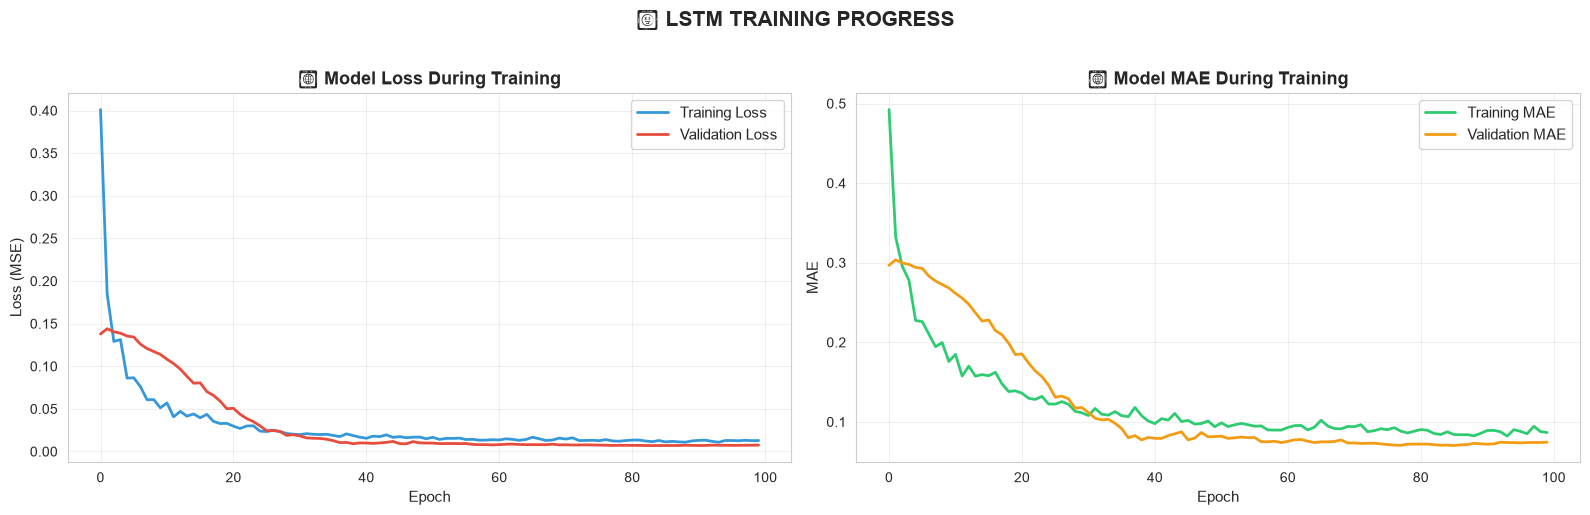


  ✅ Saved: lstm_training_history.png


In [6]:
# ============================================================
#  VISUALIZE TRAINING HISTORY
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', color='#3498db', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#e74c3c', linewidth=2)
axes[0].set_title('📉 Model Loss During Training', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE plot
axes[1].plot(history.history['mae'], label='Training MAE', color='#2ecc71', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#f39c12', linewidth=2)
axes[1].set_title('📊 Model MAE During Training', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('🧠 LSTM TRAINING PROGRESS', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: lstm_training_history.png")

In [7]:
# ============================================================
#  LSTM MODEL EVALUATION
# ============================================================

# Make predictions
y_train_pred_scaled = model.predict(X_train_lstm, verbose=0)
y_test_pred_scaled = model.predict(X_test_lstm, verbose=0)

# Inverse transform to get original scale
y_train_actual = scaler_y.inverse_transform(y_train)
y_test_actual = scaler_y.inverse_transform(y_test)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# Calculate metrics
lstm_metrics = {
    'Train_RMSE' : np.sqrt(mean_squared_error(y_train_actual, y_train_pred)),
    'Test_RMSE'  : np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),
    'Train_MAE'  : mean_absolute_error(y_train_actual, y_train_pred),
    'Test_MAE'   : mean_absolute_error(y_test_actual, y_test_pred),
    'Train_R2'   : r2_score(y_train_actual, y_train_pred),
    'Test_R2'    : r2_score(y_test_actual, y_test_pred),
}

print("=" * 65)
print("  📊 LSTM MODEL PERFORMANCE")
print("=" * 65)
print(f"\n  🏋️  TRAINING SET:")
print(f"     • RMSE     : {lstm_metrics['Train_RMSE']:.6f}")
print(f"     • MAE      : {lstm_metrics['Train_MAE']:.6f}")
print(f"     • R² Score : {lstm_metrics['Train_R2']:.6f}")

print(f"\n  🧪 TEST SET:")
print(f"     • RMSE     : {lstm_metrics['Test_RMSE']:.6f}")
print(f"     • MAE      : {lstm_metrics['Test_MAE']:.6f}")
print(f"     • R² Score : {lstm_metrics['Test_R2']:.6f}")
print("=" * 65)

  📊 LSTM MODEL PERFORMANCE

  🏋️  TRAINING SET:
     • RMSE     : 0.037706
     • MAE      : 0.030925
     • R² Score : 0.891478

  🧪 TEST SET:
     • RMSE     : 0.044175
     • MAE      : 0.036104
     • R² Score : 0.876495


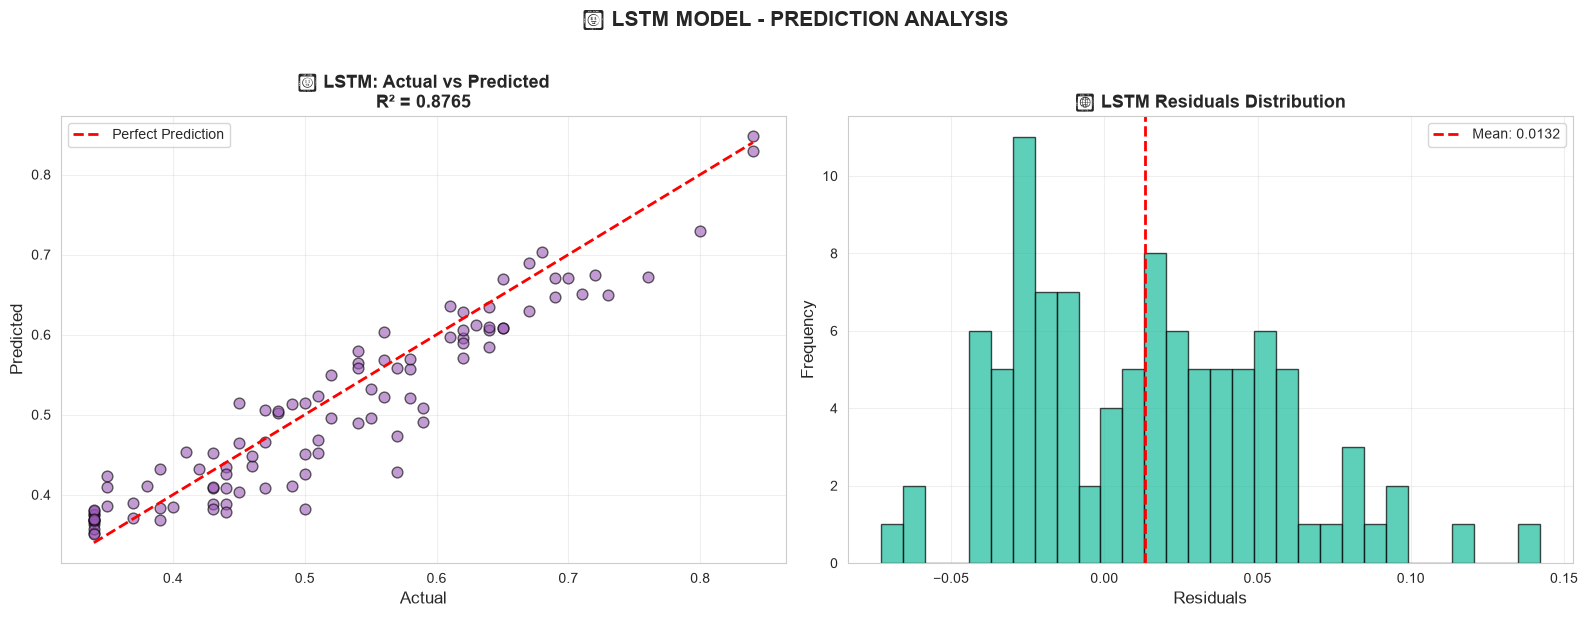


  ✅ Saved: lstm_predictions.png


In [8]:
# ============================================================
#  LSTM PREDICTIONS VISUALIZATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Actual vs Predicted
axes[0].scatter(y_test_actual, y_test_pred, alpha=0.6, 
                color='#9b59b6', edgecolors='black', s=60)
axes[0].plot([y_test_actual.min(), y_test_actual.max()],
             [y_test_actual.min(), y_test_actual.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual', fontsize=12)
axes[0].set_ylabel('Predicted', fontsize=12)
axes[0].set_title(f'🧠 LSTM: Actual vs Predicted\nR² = {lstm_metrics["Test_R2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test_actual.flatten() - y_test_pred.flatten()
axes[1].hist(residuals, bins=30, color='#1abc9c', edgecolor='black', alpha=0.7)
axes[1].axvline(residuals.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {residuals.mean():.4f}')
axes[1].set_xlabel('Residuals', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('📊 LSTM Residuals Distribution',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('🧠 LSTM MODEL - PREDICTION ANALYSIS', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: lstm_predictions.png")

  🥊 LSTM vs BEST ML MODEL vs BASELINE

📊 3-WAY COMPARISON:


,Model,Test_RMSE,Test_R2
0,Baseline (Linear Reg),0.030357,0.941676
1,Ridge Regression (Best ML),0.030367,0.941635
2,LSTM (Deep Learning),0.044175,0.876495


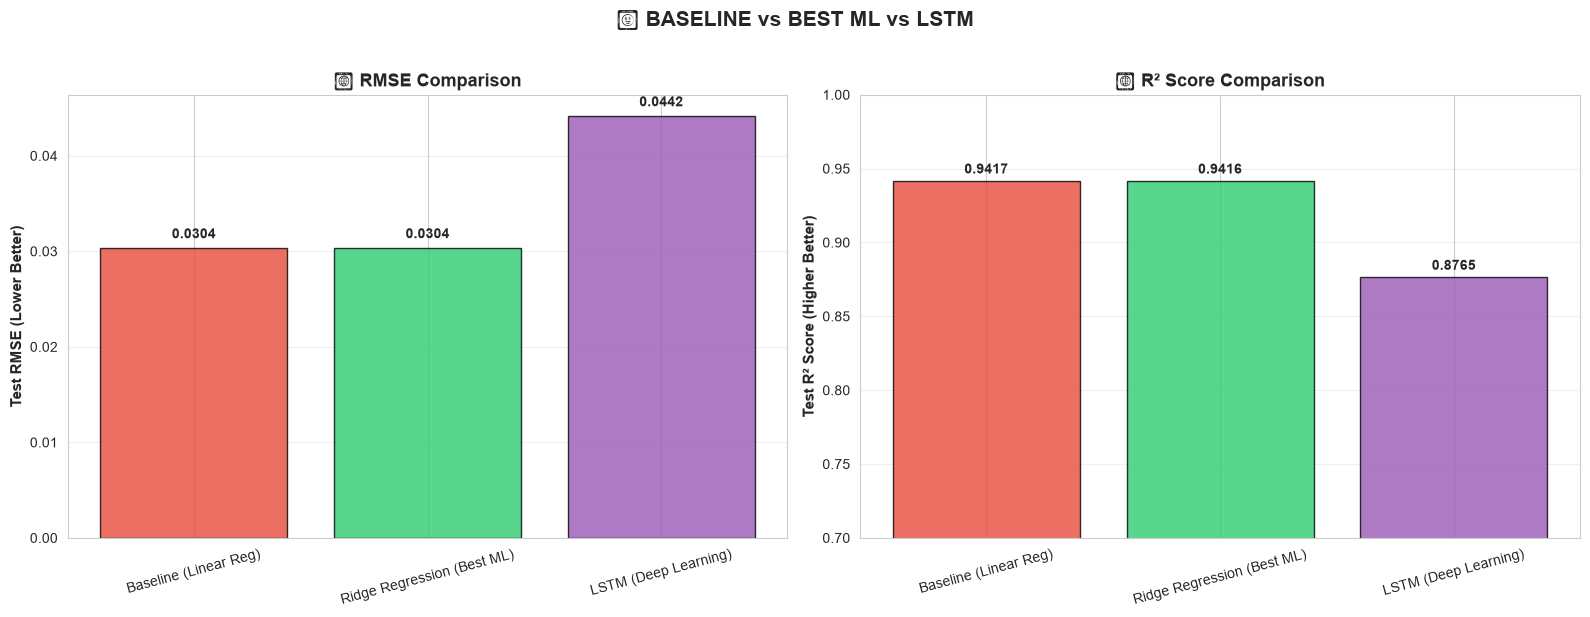


  ✅ Saved: lstm_vs_ml_comparison.png


In [9]:
# ============================================================
#  COMPARE LSTM WITH BEST ML MODEL
# ============================================================

import json

# Load best model results
with open(PROJECT_ROOT / "models" / "results" / 'FINAL_REPORT.json', 'r') as f:
    final_report = json.load(f)

best_ml_model = final_report['best_model']
baseline = final_report['baseline_model']

print("=" * 65)
print("  🥊 LSTM vs BEST ML MODEL vs BASELINE")
print("=" * 65)

comparison_data = {
    'Model': ['Baseline (Linear Reg)', f"{best_ml_model['name']} (Best ML)", 'LSTM (Deep Learning)'],
    'Test_RMSE': [
        baseline['metrics']['RMSE'],
        best_ml_model['metrics']['RMSE'],
        lstm_metrics['Test_RMSE']
    ],
    'Test_R2': [
        baseline['metrics']['R² Score'],
        best_ml_model['metrics']['R2'],
        lstm_metrics['Test_R2']
    ],
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Test_RMSE'] = comparison_df['Test_RMSE'].round(6)
comparison_df['Test_R2'] = comparison_df['Test_R2'].round(6)

print("\n📊 3-WAY COMPARISON:")
display(comparison_df)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#e74c3c', '#2ecc71', '#9b59b6']

# RMSE
axes[0].bar(comparison_df['Model'], comparison_df['Test_RMSE'], 
            color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Test RMSE (Lower Better)', fontsize=11, fontweight='bold')
axes[0].set_title('📉 RMSE Comparison', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['Test_RMSE']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# R²
axes[1].bar(comparison_df['Model'], comparison_df['Test_R2'], 
            color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Test R² Score (Higher Better)', fontsize=11, fontweight='bold')
axes[1].set_title('📈 R² Score Comparison', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison_df['Test_R2']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')
axes[1].set_ylim([0.7, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('🥊 BASELINE vs BEST ML vs LSTM', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'lstm_vs_ml_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n  ✅ Saved: lstm_vs_ml_comparison.png")

In [10]:
# ============================================================
#  💡 LSTM INSIGHTS & LEARNING SUMMARY
# ============================================================

print("=" * 65)
print("  💡 LSTM ANALYSIS - KEY INSIGHTS")
print("=" * 65)

# Compare LSTM vs Best ML
ml_r2 = best_ml_model['metrics']['R2']
lstm_r2 = lstm_metrics['Test_R2']
diff = ((lstm_r2 - ml_r2) / ml_r2) * 100

print(f"\n  🔍 INSIGHT #1: LSTM PERFORMANCE")
print("  " + "-" * 61)
print(f"     • LSTM Test R²        : {lstm_r2:.4f}")
print(f"     • Best ML Test R²     : {ml_r2:.4f}")
print(f"     • Difference          : {diff:+.2f}%")

if diff > 0:
    print(f"     → LSTM performs better on this problem!")
else:
    print(f"     → Traditional ML performs better on this small tabular dataset")

print(f"\n  🔍 INSIGHT #2: WHY THIS RESULT?")
print("  " + "-" * 61)
print(f"     • Dataset size: {len(df)} rows (small for deep learning)")
print(f"     • Data type: Tabular (not sequential)")
print(f"     • LSTM strength: Time-series & sequential data")
print(f"     • ML strength: Tabular structured data")

print(f"\n  🔍 INSIGHT #3: WHEN TO USE LSTM?")
print("  " + "-" * 61)
print(f"     ✅ Time-series forecasting")
print(f"     ✅ Sequential data (text, speech)")
print(f"     ✅ Large datasets (10,000+ samples)")
print(f"     ✅ Temporal dependencies exist")

print(f"\n  🔍 INSIGHT #4: WHAT WE LEARNED")
print("  " + "-" * 61)
print(f"     • LSTM architecture & implementation")
print(f"     • Deep learning training process")
print(f"     • Sequential data handling")
print(f"     • Model choice depends on data type!")

print("\n" + "=" * 65)
print("  ✅ LSTM EXTRA WORK COMPLETED SUCCESSFULLY!")
print("=" * 65)

  💡 LSTM ANALYSIS - KEY INSIGHTS

  🔍 INSIGHT #1: LSTM PERFORMANCE
  -------------------------------------------------------------
     • LSTM Test R²        : 0.8765
     • Best ML Test R²     : 0.9416
     • Difference          : -6.92%
     → Traditional ML performs better on this small tabular dataset

  🔍 INSIGHT #2: WHY THIS RESULT?
  -------------------------------------------------------------
     • Dataset size: 500 rows (small for deep learning)
     • Data type: Tabular (not sequential)
     • LSTM strength: Time-series & sequential data
     • ML strength: Tabular structured data

  🔍 INSIGHT #3: WHEN TO USE LSTM?
  -------------------------------------------------------------
     ✅ Time-series forecasting
     ✅ Sequential data (text, speech)
     ✅ Large datasets (10,000+ samples)
     ✅ Temporal dependencies exist

  🔍 INSIGHT #4: WHAT WE LEARNED
  -------------------------------------------------------------
     • LSTM architecture & implementation
     • Deep learni

---

## 🧠 LSTM Extra Work - Complete Summary

### ✅ What We Learned:

| Topic | Details |
|-------|---------|
| 🧠 LSTM Concept | Long Short-Term Memory networks |
| 🏗️ Architecture | Multi-layer LSTM with dropout & batch norm |
| 🔧 Implementation | TensorFlow/Keras from scratch |
| 📊 Training Process | With callbacks (early stopping, LR reduction) |
| 🥊 Comparison | LSTM vs Traditional ML models |

### 📊 LSTM Model Architecture: